In [40]:
import pandas as pd

df = pd.read_csv("Sales_data.csv")


In [41]:
df.shape

(9994, 19)

In [42]:
df.columns.tolist()

['order_id',
 'order_date',
 'ship_date',
 'customer',
 'manufactory',
 'product_name',
 'segment',
 'category',
 'subcategory',
 'region',
 'zip',
 'city',
 'state',
 'country',
 'discount',
 'profit',
 'quantity',
 'sales',
 'profit_margin']

In [43]:
df.head()

,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin
0,US-2020-103800,1/3/2019,1/7/2019,Darren Powers,Message Book,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Consumer,Office Supplies,Paper,Central,77095,Houston,Texas,United States,0.2,5.5512,2,16.448,0.3375
1,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,GBC,GBC Standard Plastic Binding Systems Combs,Home Office,Office Supplies,Binders,Central,60540,Naperville,Illinois,United States,0.8,-5.4870,2,3.540,-1.5500
2,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,Avery,Avery 508,Home Office,Office Supplies,Labels,Central,60540,Naperville,Illinois,United States,0.2,4.2717,3,11.784,0.3625
3,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,SAFCO,SAFCO Boltless Steel Shelving,Home Office,Office Supplies,Storage,Central,60540,Naperville,Illinois,United States,0.2,-64.7748,3,272.736,-0.2375
4,US-2020-141817,1/5/2019,1/12/2019,Mick Brown,Avery,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Consumer,Office Supplies,Art,East,19143,Philadelphia,Pennsylvania,United States,0.2,4.8840,3,19.536,0.2500


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       9994 non-null   str    
 1   order_date     9994 non-null   str    
 2   ship_date      9994 non-null   str    
 3   customer       9994 non-null   str    
 4   manufactory    9994 non-null   str    
 5   product_name   9994 non-null   str    
 6   segment        9994 non-null   str    
 7   category       9994 non-null   str    
 8   subcategory    9994 non-null   str    
 9   region         9994 non-null   str    
 10  zip            9994 non-null   int64  
 11  city           9994 non-null   str    
 12  state          9994 non-null   str    
 13  country        9994 non-null   str    
 14  discount       9994 non-null   float64
 15  profit         9994 non-null   float64
 16  quantity       9994 non-null   int64  
 17  sales          9994 non-null   float64
 18  profit_margin  9994

In [45]:
df.describe()

,zip,discount,profit,quantity,sales,profit_margin
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.371723,0.156203,28.656896,3.789574,229.858001,0.120314
std,32063.705315,0.206452,234.260108,2.225110,623.245101,0.466754
min,1040.000000,0.000000,-6599.978000,1.000000,0.444000,-2.750000
25%,23223.000000,0.000000,1.728750,2.000000,17.280000,0.075000
50%,56430.500000,0.200000,8.666500,3.000000,54.490000,0.270000
75%,90008.000000,0.200000,29.364000,5.000000,209.940000,0.362500
max,99301.000000,0.800000,8399.976000,14.000000,22638.480000,0.500000


In [46]:
df.isnull().sum()

order_id         0
order_date       0
ship_date        0
customer         0
manufactory      0
product_name     0
segment          0
category         0
subcategory      0
region           0
zip              0
city             0
state            0
country          0
discount         0
profit           0
quantity         0
sales            0
profit_margin    0
dtype: int64

In [47]:
df.duplicated().sum()

np.int64(1)

In [48]:
df.dtypes

order_id             str
order_date           str
ship_date            str
customer             str
manufactory          str
product_name         str
segment              str
category             str
subcategory          str
region               str
zip                int64
city                 str
state                str
country              str
discount         float64
profit           float64
quantity           int64
sales            float64
profit_margin    float64
dtype: object

In [49]:
# Unique values for categorical columns

categorical_columns = [
    'customer',
    'manufactory',
    'product_name',
    'segment',
    'category',
    'subcategory',
    'region',
    'city',
    'state',
    'country'
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique())


customer:
793

manufactory:
182

product_name:
1849

segment:
3

category:
3

subcategory:
17

region:
4

city:
531

state:
49

country:
1


In [50]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (9993, 19)


In [51]:
# Converting dates

df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

print(df[['order_date', 'ship_date']].dtypes)

order_date    datetime64[us]
ship_date     datetime64[us]
dtype: object


In [52]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Dataset shape:", df.shape)

Missing values: 0
Duplicate rows: 0
Dataset shape: (9993, 19)


In [53]:
###  Basic EDA

In [54]:
# Overall sales, profit, and quantity

print("Total Sales:", df['sales'].sum())
print("Total Profit:", df['profit'].sum())
print("Total Quantity Sold:", df['quantity'].sum())
print("Average Order Sales:", df['sales'].mean())
print("Average Profit Margin:", df['profit_margin'].mean())

Total Sales: 2296919.4883
Total Profit: 286409.08050000004
Total Quantity Sold: 37871
Average Order Sales: 229.85284582207544
Average Profit Margin: 0.12033025825898128


In [55]:
# Number of unique customers and products

print("Unique Customers:", df['customer'].nunique())
print("Unique Products:", df['product_name'].nunique())
print("Unique Categories:", df['category'].nunique())
print("Unique Regions:", df['region'].nunique())

Unique Customers: 793
Unique Products: 1849
Unique Categories: 3
Unique Regions: 4


In [56]:
# Sales by category

category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)

category_sales

category
Technology         836154.0330
Furniture          741718.4233
Office Supplies    719047.0320
Name: sales, dtype: float64

In [57]:
# Sales by region

region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)

region_sales

region
West       725457.8245
East       678499.8680
Central    501239.8908
South      391721.9050
Name: sales, dtype: float64

In [58]:
"""
Current findings:
Total Sales: 2,296,919.49
Total Profit: 286,409.08
Total Quantity Sold: 37,871
Average Sales per Record: 229.85
Average Profit Margin: 12.03%
Unique Customers: 793
Unique Products: 1,849

Category-wise sales:
Technology: 836,154.03
Furniture: 741,718.42
Office Supplies: 719,047.03

Technology has the highest sales.

Region-wise sales:
West: 725,457.82
East: 678,499.87
Central: 501,239.89
South: 391,721.91

West is the highest-performing region, while South has the lowest sales.
"""

'\nCurrent findings:\nTotal Sales: 2,296,919.49\nTotal Profit: 286,409.08\nTotal Quantity Sold: 37,871\nAverage Sales per Record: 229.85\nAverage Profit Margin: 12.03%\nUnique Customers: 793\nUnique Products: 1,849\n\nCategory-wise sales:\nTechnology: 836,154.03\nFurniture: 741,718.42\nOffice Supplies: 719,047.03\n\nTechnology has the highest sales.\n\nRegion-wise sales:\nWest: 725,457.82\nEast: 678,499.87\nCentral: 501,239.89\nSouth: 391,721.91\n\nWest is the highest-performing region, while South has the lowest sales.\n'

In [59]:
# Monthly Sales Trend

df['year_month'] = df['order_date'].dt.to_period('M')

In [60]:
# Calculate monthly sales

monthly_sales = df.groupby('year_month')['sales'].sum()

monthly_sales

year_month
2019-01     14236.8950
2019-02      4519.8920
2019-03     55691.0090
2019-04     28013.9730
2019-05     23648.2870
2019-06     34595.1276
2019-07     33946.3930
2019-08     27909.4685
2019-09     81777.3508
2019-10     31453.3930
2019-11     78628.7167
2019-12     69545.6205
2020-01     18174.0756
2020-02     11951.4110
2020-03     38726.2520
2020-04     34195.2085
2020-05     30131.6865
2020-06     24797.2920
2020-07     28765.3250
2020-08     36898.3322
2020-09     64595.9180
2020-10     31404.9235
2020-11     75972.5635
2020-12     74919.5212
2021-01     18542.4910
2021-02     22978.8150
2021-03     51715.8750
2021-04     38750.0390
2021-05     56987.7280
2021-06     40344.5340
2021-07     39261.9630
2021-08     31115.3743
2021-09     73410.0249
2021-10     59687.7450
2021-11     79411.9658
2021-12     96999.0430
2022-01     43971.3740
2022-02     20301.1334
2022-03     58872.3528
2022-04     36521.5361
2022-05     44261.1102
2022-06     52981.7257
2022-07     45264.4160


In [61]:
# Finding the best and worst sales months

best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

worst_month = monthly_sales.idxmin()
worst_month_sales = monthly_sales.min()

print("Best Sales Month:", best_month)
print("Best Month Sales:", best_month_sales)

print("Lowest Sales Month:", worst_month)
print("Lowest Month Sales:", worst_month_sales)

Best Sales Month: 2022-11
Best Month Sales: 118447.825
Lowest Sales Month: 2019-02
Lowest Month Sales: 4519.892


In [62]:
"""
Monthly Sales Findings
Highest sales month: November 2022 — 118,447.83
Lowest sales month: February 2019 — 4,519.89
The data covers January 2019 to December 2022.
Sales generally show stronger values toward the end of several years, especially around November and December.
"""

'\nMonthly Sales Findings\nHighest sales month: November 2022 — 118,447.83\nLowest sales month: February 2019 — 4,519.89\nThe data covers January 2019 to December 2022.\nSales generally show stronger values toward the end of several years, especially around November and December.\n'

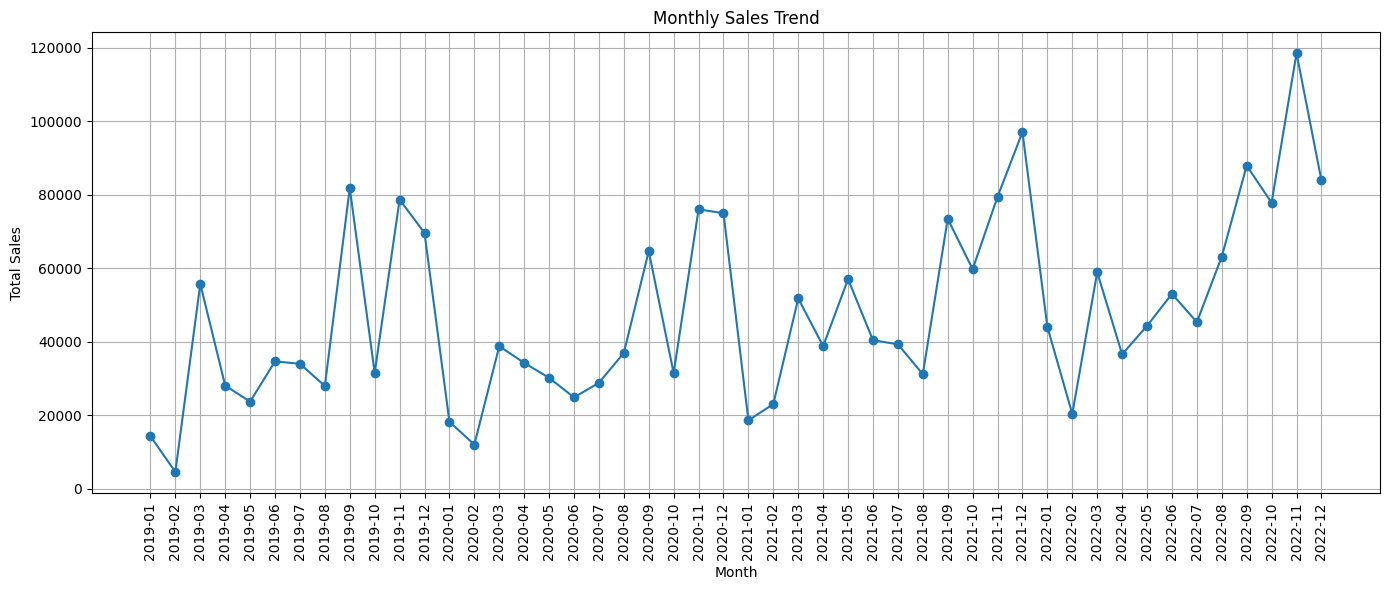

In [63]:
# Monthly Sales Trend

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

In [64]:
# Top 10 products by sales

top_products_sales = (
    df.groupby('product_name')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_sales

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64

In [65]:
# Top 10 products by quantity sold
# sales value vs. units sold:
top_products_quantity = (
    df.groupby('product_name')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity

product_name
Staples                                                       215
Staple envelope                                               170
Easy-staple paper                                             150
Staples in misc. colors                                        86
KI Adjustable-Height Table                                     74
Avery Non-Stick Binders                                        71
Storex Dura Pro Binders                                        71
GBC Premium Transparent Covers with Diagonal Lined Pattern     67
Situations Contoured Folding Chairs, 4/Set                     64
Staple-based wall hangings                                     62
Name: quantity, dtype: int64

In [66]:
# Best-selling product

print("Top Product by Sales:", top_products_sales.index[0])
print("Sales:", top_products_sales.iloc[0])

print("\nTop Product by Quantity:", top_products_quantity.index[0])
print("Quantity:", top_products_quantity.iloc[0])

Top Product by Sales: Canon imageCLASS 2200 Advanced Copier
Sales: 61599.824

Top Product by Quantity: Staples
Quantity: 215


In [67]:
"""
Best-selling product findings:

By total sales value:

Canon imageCLASS 2200 Advanced Copier — 61,599.82
Fellowes PB500 Electric Punch — 27,453.38
Cisco TelePresence System EX90 — 22,638.48
HON 5400 Series Task Chairs — 21,870.58
GBC DocuBind TL300 — 19,823.48

Canon imageCLASS 2200 Advanced Copier is the top product by sales.

By quantity sold:

Staples — 215
Staple envelope — 170
Easy-staple paper — 150
Staples in misc. colors — 86
KI Adjustable-Height Table — 74

Staples is the most frequently sold product by quantity.
"""

'\nBest-selling product findings:\n\nBy total sales value:\n\nCanon imageCLASS 2200 Advanced Copier — 61,599.82\nFellowes PB500 Electric Punch — 27,453.38\nCisco TelePresence System EX90 — 22,638.48\nHON 5400 Series Task Chairs — 21,870.58\nGBC DocuBind TL300 — 19,823.48\n\nCanon imageCLASS 2200 Advanced Copier is the top product by sales.\n\nBy quantity sold:\n\nStaples — 215\nStaple envelope — 170\nEasy-staple paper — 150\nStaples in misc. colors — 86\nKI Adjustable-Height Table — 74\n\nStaples is the most frequently sold product by quantity.\n'

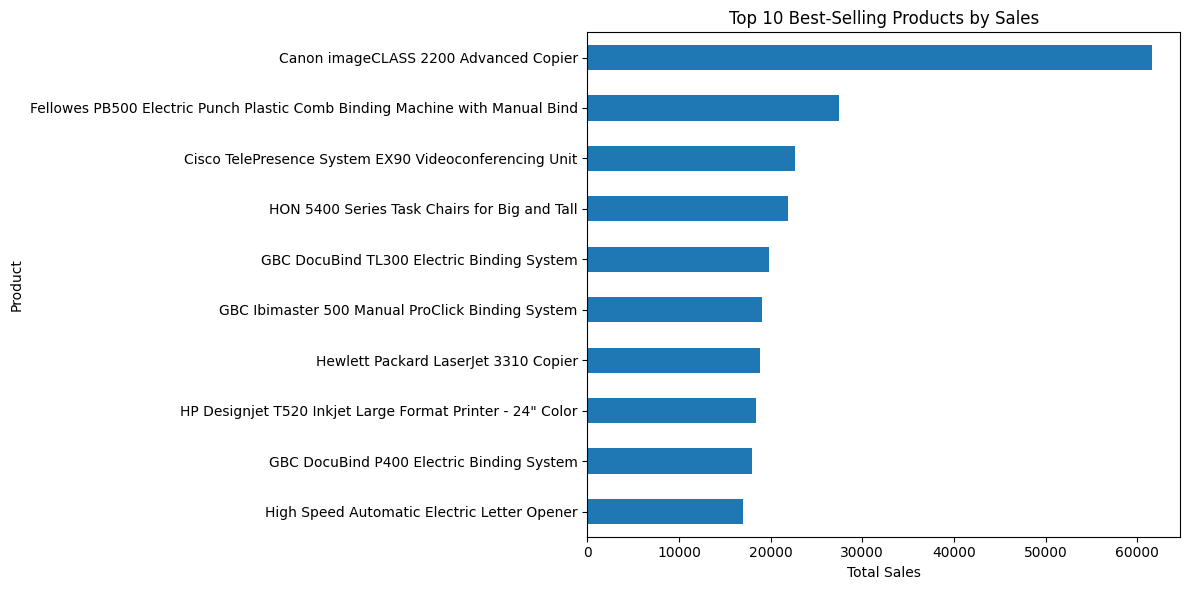

In [68]:
# Top 10 Best-Selling Products visualization

plt.figure(figsize=(12, 6))

top_products_sales.sort_values().plot(kind='barh')

plt.title('Top 10 Best-Selling Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [69]:
### Customer Analysis

In [70]:
# Top 10 customers by sales

top_customers_sales = (
    df.groupby('customer')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers_sales

customer
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: sales, dtype: float64

In [71]:
# Top 10 customers by profit

top_customers_profit = (
    df.groupby('customer')['profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers_profit

customer
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: profit, dtype: float64

In [72]:
# Overall customer insights

customer_summary = (
    df.groupby('customer')
    .agg(
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        total_quantity=('quantity', 'sum'),
        orders=('order_id', 'nunique')
    )
    .sort_values('total_sales', ascending=False)
)

customer_summary.head(10)

,total_sales,total_profit,total_quantity,orders
customer,,,,
Sean Miller,25043.050,-1980.7393,50,5
Tamara Chand,19052.218,8981.3239,42,5
Raymond Buch,15117.339,6976.0959,71,6
Tom Ashbrook,14595.620,4703.7883,36,4
Adrian Barton,14473.571,5444.8055,73,10
Ken Lonsdale,14175.229,806.8550,113,12
Sanjit Chand,14142.334,5757.4119,87,9
Hunter Lopez,12873.298,5622.4292,50,6
Sanjit Engle,12209.438,2650.6769,78,11


In [73]:
"""
Top customer by sales:
Sean Miller — 25,043.05

However, there's an important insight here:

Sean Miller generated the highest sales, but had negative total profit of -1,980.74.
Tamara Chand generated 19,052.22 in sales but the highest profit: 8,981.32.
Raymond Buch generated 15,117.34 in sales and 6,976.10 profit.
Adrian Barton had 73 units across 10 orders, showing relatively frequent purchasing.
Ken Lonsdale purchased the highest quantity among these top customers (113 units) but generated only 806.86 profit.
"""

"\nTop customer by sales:\nSean Miller — 25,043.05\n\nHowever, there's an important insight here:\n\nSean Miller generated the highest sales, but had negative total profit of -1,980.74.\nTamara Chand generated 19,052.22 in sales but the highest profit: 8,981.32.\nRaymond Buch generated 15,117.34 in sales and 6,976.10 profit.\nAdrian Barton had 73 units across 10 orders, showing relatively frequent purchasing.\nKen Lonsdale purchased the highest quantity among these top customers (113 units) but generated only 806.86 profit.\n"

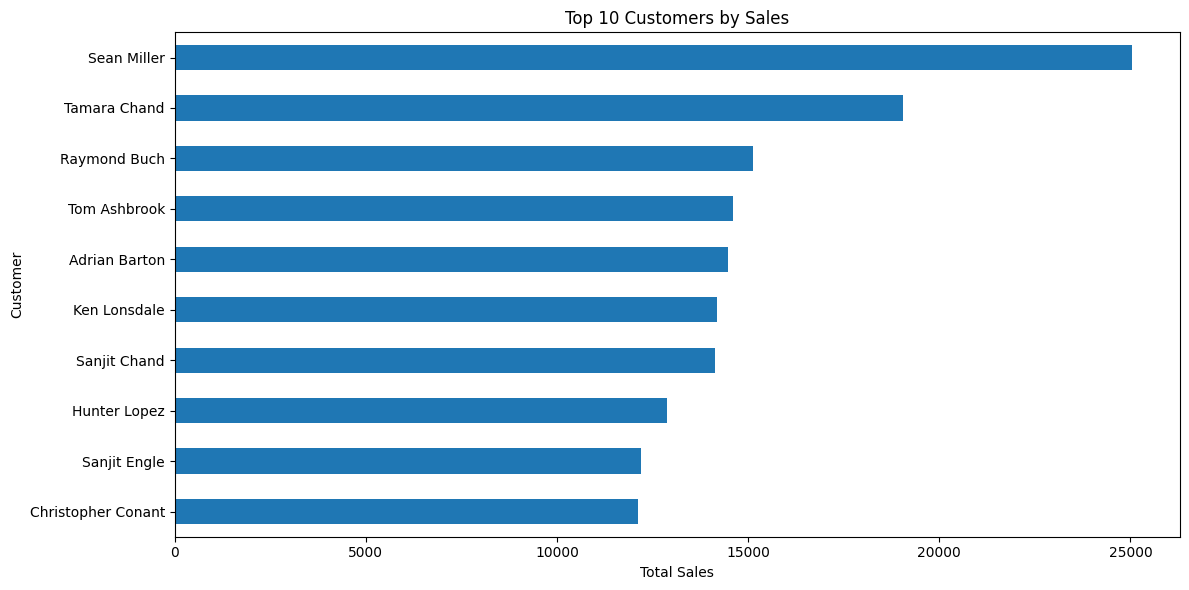

In [74]:
plt.figure(figsize=(12, 6))

top_customers_sales.sort_values().plot(kind='barh')

plt.title('Top 10 Customers by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Customer')
plt.tight_layout()
plt.show()

In [75]:
### Region & Category Analysis

In [76]:
# Region-wise sales and profit

region_summary = (
    df.groupby('region')
    .agg(
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        total_quantity=('quantity', 'sum')
    )
    .sort_values('total_sales', ascending=False)
)

region_summary

,total_sales,total_profit,total_quantity
region,,,
West,725457.8245,108418.4489,12266
East,678499.8680,91534.8388,10616
Central,501239.8908,39706.3625,8780
South,391721.9050,46749.4303,6209


In [77]:
# Category-wise sales and profit

category_summary = (
    df.groupby('category')
    .agg(
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        total_quantity=('quantity', 'sum')
    )
    .sort_values('total_sales', ascending=False)
)

category_summary

,total_sales,total_profit,total_quantity
category,,,
Technology,836154.0330,145454.9481,6939
Furniture,741718.4233,18463.3316,8026
Office Supplies,719047.0320,122490.8008,22906


In [78]:
# Region × Category analysis

region_category_sales = pd.pivot_table(
    df,
    values='sales',
    index='region',
    columns='category',
    aggfunc='sum'
)

region_category_sales

category,Furniture,Office Supplies,Technology
region,,,
Central,163797.1638,167026.415,170416.312
East,208009.8320,205516.055,264973.981
South,117298.6840,125651.313,148771.908
West,252612.7435,220853.249,251991.832


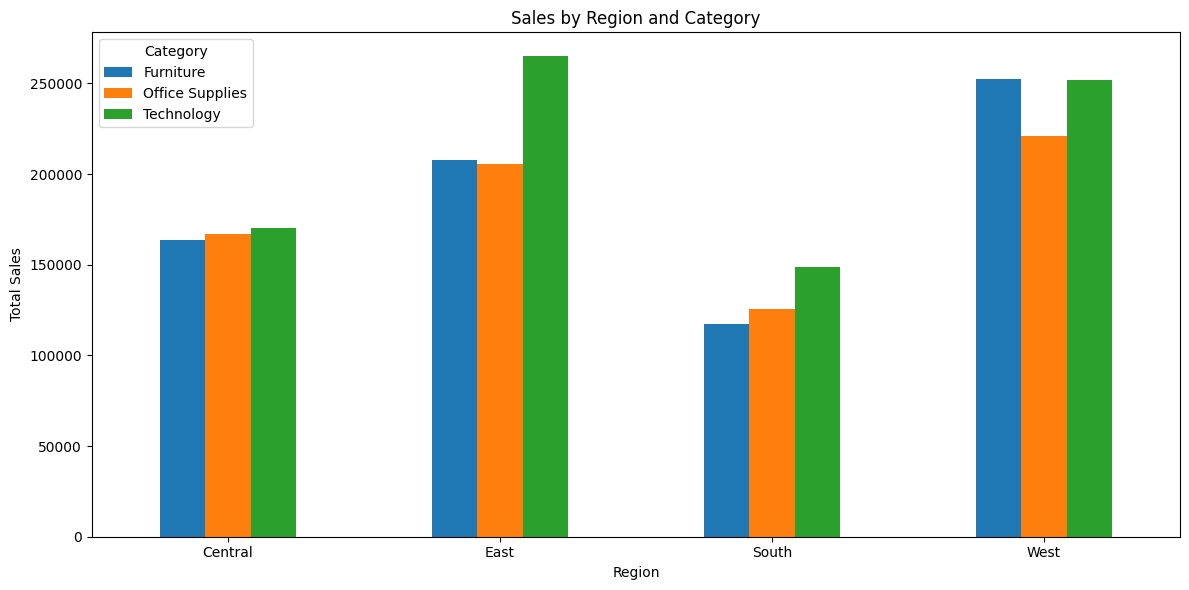

In [79]:
region_category_sales.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Sales by Region and Category')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

In [80]:
category_profit = (
    df.groupby('category')['profit']
    .sum()
    .sort_values(ascending=False)
)

category_profit

category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18463.3316
Name: profit, dtype: float64

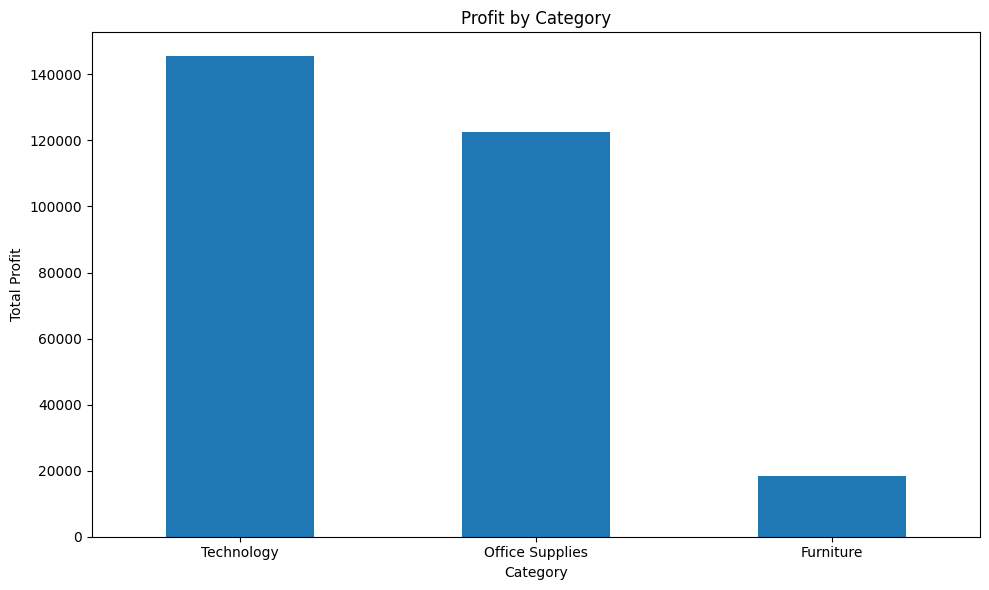

In [81]:
plt.figure(figsize=(10, 6))

category_profit.plot(kind='bar')

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [82]:
print("===== Sales Data Analysis Summary =====")
print("Total Sales:", round(df['sales'].sum(), 2))
print("Total Profit:", round(df['profit'].sum(), 2))
print("Total Quantity Sold:", df['quantity'].sum())
print("Unique Customers:", df['customer'].nunique())
print("Unique Products:", df['product_name'].nunique())
print("Best Sales Month:", best_month)
print("Best Month Sales:", round(best_month_sales, 2))
print("Top Product by Sales:", top_products_sales.index[0])
print("Top Product Sales:", round(top_products_sales.iloc[0], 2))
print("Top Region:", region_sales.index[0])
print("Top Category:", category_sales.index[0])

===== Sales Data Analysis Summary =====
Total Sales: 2296919.49
Total Profit: 286409.08
Total Quantity Sold: 37871
Unique Customers: 793
Unique Products: 1849
Best Sales Month: 2022-11
Best Month Sales: 118447.82
Top Product by Sales: Canon imageCLASS 2200 Advanced Copier
Top Product Sales: 61599.82
Top Region: West
Top Category: Technology
